In [1]:
import numpy as np
import pandas as pd
import sys
from collections import namedtuple
from torch import autograd
from typing import Dict, List, Tuple, Optional
import matplotlib.pyplot as plt
import os
from pathlib import Path
import torch
import torch.nn as nn
from gym import spaces
from maddpg_agent_v2_test import Agent
import time
from collections import defaultdict


In [2]:
class MultiAgentEnergyStorageEnv:
    def __init__(self,
                 data_path: str = None,
                 num_agents: int = 3,
                 user_type_distribution: Dict[int, int] = {0: 1, 1: 1, 2: 1},
                 episode_length: int =96,
                 battery_capacity: float = 2,
                 max_charge_rate: float = 0.2,
                 efficiency: float = 0.95,
                 init_soc: float = 0.5,
                 seed: int = 42):
        self.user_type_distribution = user_type_distribution
        self.num_agents = num_agents #sum(user_type_distribution.values())

        self.episode_length = episode_length
        self.battery_capacity = battery_capacity
        self.max_charge_rate = max_charge_rate
        self.efficiency = efficiency
        self.init_soc = init_soc
        # self.seed = seed
        self.charge_power = None
        # np.random.seed(seed)

        if data_path is None:
            if 'ipykernel' in sys.modules:  # Jupyter
                data_path = Path.cwd().parent / "data" / "opsd_building.csv"
            else:  # Normal Python
                data_path = Path(__file__).parent.parent / "data" / "opsd_building.csv"

        # load
        self.raw_data = self._load_data(data_path)

        # 计算标准化参数（从训练数据计算）
        self.normalization_params = self._calculate_normalization_params()
        
        self.load_profiles = self._process_load_data()

        # check data
        self._validate_data()
        
        # 初始化历史记录容器
        self._init_history_containers()

        # 初始化状态
        self.reset()

    def _load_data(self, data_path: str) -> pd.DataFrame:
        """from csv file"""
        try:
            data = pd.read_csv(data_path)
            print("Data loaded successfully, first 5 rows example:")
            print(data.head())
            return data
        except Exception as e:
            raise ValueError(f"Unable to load data file: {e}")
        
    def _calculate_normalization_params(self) -> Dict[str, float]:
        """计算标准化所需参数"""
        params = {}
        
        # 1. 电价标准化参数 (Z-score)
        prices = self.raw_data.iloc[:, -1].values  # 最后一列是电价
        params['price_mean'] = np.mean(prices)
        params['price_std'] = np.std(prices)
        
        # 2. 负荷标准化参数 (Z-score)
        load_cols = [f"load{i+1}" for i in range(self.num_agents)]
        all_loads = self.raw_data[load_cols].values.flatten()
        params['load_mean'] = np.mean(all_loads)
        params['load_std'] = np.std(all_loads)

        return params
    
    def _process_load_data(self) -> Dict[int, pd.DataFrame]:
        """处理负荷数据并为每个agent创建负荷曲线"""
        load_cols = [f"load{i+1}" for i in range(self.num_agents)]
        missing_cols = [col for col in load_cols if col not in self.raw_data.columns]
        if missing_cols:
            raise ValueError(f"数据文件中缺失负荷列: {missing_cols}")
        
        num_rows = self.raw_data.shape[0]
        num_days = num_rows // self.episode_length
        
        # 提取原始数据
        load_data = self.raw_data.iloc[:, 1:4].values  # 形状: (num_rows, 3)
        price_data = self.raw_data.iloc[:, -1].values  # 最后一列是电价
        
        load_profiles = {}
        day_idx = np.random.randint(0, num_days)  # 为所有agent随机选择同一天
        
        for agent_id in range(self.num_agents):
            start = day_idx * self.episode_length
            end = start + self.episode_length
            
            # 应用标准化
            agent_load = (load_data[start:end, agent_id] - self.normalization_params['load_mean']) / self.normalization_params['load_std']
            agent_price = (price_data[start:end] - self.normalization_params['price_mean']) / self.normalization_params['price_std']
            
            # 创建DataFrame
            df = pd.DataFrame({
                'period': np.arange(self.episode_length),
                'load': agent_load,
                'price': agent_price
            })
            load_profiles[agent_id] = df
            
        return load_profiles
    
    def _validate_data(self):
        """Verify data integrity and length"""
        # 检查负荷数据
        for agent_id, profile in self.load_profiles.items():
            if len(profile) < self.episode_length:
                raise ValueError(f"The payload data length is insufficient and needs to be at least{self.episode_length}time points")
        print(f"data check pass,A total of {len(self.raw_data)}row of data is loaded")


    def action_space(self, agent_name=None):
        single_action_space = spaces.Box(
            low=-self.max_charge_rate,
            high=self.max_charge_rate,
            shape=(1,),
            dtype=np.float32
        )
        
        if agent_name is not None:
            return single_action_space
        else:
            return {agent_id: single_action_space for agent_id in range(self.num_agents)}
    
    def _get_single_observation(self, agent_id: int) -> np.ndarray:
        """获取单个agent的标准化观察值"""
        # 时间编码 (已标准化在[-1,1])
        angle = 2 * np.pi * self.current_step / 96
        time_sin = np.sin(angle)
        time_cos = np.cos(angle)
        
        # 使用标准化后的数据
        current_price = self.load_profiles[agent_id]['price'].iloc[self.current_step].item()
        current_load = self.load_profiles[agent_id]['load'].iloc[self.current_step].item()
        
        # SOC标准化到[-1,1]
        soc_value = float(self.battery_soc[agent_id])
        current_soc = soc_value * 2.0 - 1.0

        return np.array([time_sin, time_cos, current_price, current_load, current_soc], dtype=np.float32)
    
    def _init_history_containers(self):
        """初始化历史记录容器"""
        # 保留有用的历史记录
        self.charge_history = defaultdict(list)  # 每个agent的充放电功率历史
        self.soc_history = defaultdict(list)      # 每个agent的SOC历史
        self.price_history = []                   # 全局电价历史
        self.net_load_history = []                 # 平均净负荷历史

    def reset(self) -> Dict[int, np.ndarray]:
        """重置环境到初始状态"""
        self.current_step = 0
        self.battery_soc = {agent_id: float(self.init_soc) for agent_id in range(self.num_agents)}

        # 清空每一代的历史记录
        self.charge_history.clear()
        self.soc_history.clear()
        self.price_history.clear()
        self.net_load_history.clear()
        
        # 记录初始SOC与负荷
        for agent_id in range(self.num_agents):
            self.soc_history[agent_id].append(self.battery_soc[agent_id])
        self.load_profiles = self._process_load_data()
        
        # 获取初始观察值
        return {agent_id: self._get_single_observation(agent_id) for agent_id in range(self.num_agents)}
    

    def step(self, actions: Dict[int, float]) -> Tuple[Dict[int, np.ndarray], Dict[int, float], bool, Dict]:

        """执行一个时间步的环境动态"""
        # 获取当前负荷和电价（已标准化）
        current_loads = {
            agent_id: self.load_profiles[agent_id]['load'].iloc[self.current_step]
            for agent_id in range(self.num_agents)
        }
        current_price = self.load_profiles[0]['price'].iloc[self.current_step]

        # 执行电池动态
        net_loads = {}
        individual_costs = {}

        for agent_id, action in actions.items():
            # 限制充电功率在允许范围内
            recharge_power = action * 2 * self.max_charge_rate - self.max_charge_rate # 将动作从[-1, 1]映射到[-max_charge_rate, max_charge_rate]
            charge_power = np.clip(recharge_power, -self.max_charge_rate, self.max_charge_rate)
            charge_power=charge_power.item()  # 转换为标量
            # 计算SOC变化
            if charge_power >= 0:
                delta_soc = (charge_power * self.efficiency) / self.battery_capacity
            else:
                delta_soc = (charge_power / self.efficiency) / self.battery_capacity
            new_soc = self.battery_soc[agent_id] + delta_soc

            # 边界检查和修正
            if new_soc > 0.95:
                # 计算最大可充电量（考虑效率）
                available_space = 0.95 - self.battery_soc[agent_id]
                max_chargeable = available_space * self.battery_capacity / self.efficiency
                charge_power = min(charge_power, max_chargeable)
                new_soc = 0.95
                
            elif new_soc < 0.05:
                # 计算最大可放电量（考虑效率）
                available_energy = self.battery_soc[agent_id] - 0.05
                max_dischargeable = available_energy * self.battery_capacity * self.efficiency
                charge_power = max(charge_power, -max_dischargeable)
                new_soc = 0.05
                
            # 更新电池状态
            self.battery_soc[agent_id] = new_soc
            # 记录充电功率和SOC
            self.charge_history[agent_id].append(charge_power)
            self.soc_history[agent_id].append(new_soc)


            # 计算净负荷和成本（使用真实价格）
            real_price = float(self.denormalize_price(current_price))
            real_load = float(self.denormalize_load(current_loads[agent_id]))
            net_load = real_load + charge_power
            individual_cost = net_load * real_price
            individual_costs[agent_id] = individual_cost
            
            net_loads[agent_id] = net_load

        # 记录全局数据
        self.price_history.append(real_price)
        average_net_load = np.mean(list(net_loads.values()))
        self.net_load_history.append(average_net_load)

        # 获取下一个观察值
        next_observations = {}
        if self.current_step < self.episode_length - 1:
            next_observations = {agent_id: self._get_single_observation(agent_id) for agent_id in range(self.num_agents)}
            
        # 计算奖励
        rewards = self._calculate_rewards(individual_costs, average_net_load)
        
        # 检查episode是否结束
        self.current_step += 1
        done = {agent_id: self.current_step >= self.episode_length - 1 for agent_id in range(self.num_agents)}
    

        # 构建信息字典
        info = {
            'average_net_load': average_net_load,
            'average_cost': np.mean(list(individual_costs.values())),
            'peak_load': max(self.net_load_history) if self.net_load_history else 0,
            'valley_load': min(self.net_load_history) if self.net_load_history else 0,
            'current_period': self.current_step
        }
        
        return next_observations, rewards, done, info

    def denormalize_price(self, normalized_price):
        """将标准化电价反标准化为真实价格"""
        return normalized_price * self.normalization_params['price_std'] + self.normalization_params['price_mean']

    def denormalize_load(self, normalized_load):
        """将标准化负荷反标准化为真实负荷"""
        return normalized_load * self.normalization_params['load_std'] + self.normalization_params['load_mean']

    def _calculate_rewards(self, individual_costs: Dict[int, float], average_net_load: float) -> Dict[int, float]:
        """计算奖励（优化版本）"""
        # 如果没有历史记录，使用当前值
        if not self.net_load_history:
            hist_peak=0
            hist_valley=0
        else:
            # 计算历史峰值和谷值（排除当前值）
            hist_peak = max(self.net_load_history)
            hist_valley = min(self.net_load_history)
        
        # 计算峰值和谷值惩罚
        peak_penalty = max(0, (average_net_load - hist_peak)** 2) 
        valley_penalty = max(0, (hist_valley - average_net_load)** 2) 
        
        # 合并惩罚并转换为奖励
        netload_penalty = (peak_penalty + valley_penalty) / 2
        netload_reward = -netload_penalty
        
        # 计算个体奖励
        rewards = {}
        for agent_id, cost in individual_costs.items():
            # 主要奖励：最小化成本（负成本即正奖励）
            base_reward = -cost
            
            # 全局奖励：负载曲线平滑
            shared_reward = 10* netload_reward / self.num_agents
            
            # 组合奖励（避免过度强调全局目标）
            rewards[agent_id] = 1 * base_reward + 0 *shared_reward
        # print(f"当前时间步: {self.current_step}, 平均净负荷: {average_net_load:.2f}, 奖励: {rewards}")
        return rewards

    def close(self):
        print("环境已关闭")

In [3]:
#测试_calculate_rewards函数
if __name__ == "__main__":
    env = MultiAgentEnergyStorageEnv()
    obs = env.reset()
    print("初始观察值:", obs)
    actions = {0: 0.5, 1: -0.3, 2: 0.1}
    next_obs, rewards, done, info = env.step(actions)
    print("下一步观察值:", next_obs)
    print("奖励:", rewards)
    print("是否结束:", done)
    print("信息:", info)

Data loaded successfully, first 5 rows example:
     unixtime  load1  load2  load3  price
0  1432223100  0.079  0.187  0.039  29.93
1  1432224000  0.078  0.000  0.031  29.93
2  1432224900  0.080  0.000  0.075  29.62
3  1432225800  0.110  0.000  0.176  29.62
4  1432226700  0.107  0.135  0.541  29.62
data check pass,A total of 63456row of data is loaded
初始观察值: {0: array([ 0.        ,  1.        , -0.5297338 , -0.14514437,  0.        ],
      dtype=float32), 1: array([ 0.        ,  1.        , -0.5297338 , -0.83294797,  0.        ],
      dtype=float32), 2: array([ 0.       ,  1.       , -0.5297338, -0.8023789,  0.       ],
      dtype=float32)}
下一步观察值: {0: array([ 0.        ,  1.        , -0.5297338 , -0.14514437,  0.        ],
      dtype=float32), 1: array([ 0.        ,  1.        , -0.5297338 , -0.83294797, -0.21052632],
      dtype=float32), 2: array([ 0.        ,  1.        , -0.5297338 , -0.8023789 , -0.16842106],
      dtype=float32)}
奖励: {0: -2.1717, 1: 4.8260000000000005, 2: 3.7

In [ ]:
# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
NUM_EPISODE = 500
NUM_STEP = 96
NUM_AGENT = 3
WARMUP_EPISODES = NUM_EPISODE/2

LR_ACTOR = 0.001
LR_CRITIC = 0.001
HIDDEN_DIM = 128
GAMMA = 0.99
TAU = 0.01
MEMORY_SIZE = 5000
BATCH_SIZE = 256
TARGET_UPDATE_INTERVAL = 100 #这里不能乱动，不然除不尽的话没法更新

PRINT_INTERVAL = 50
highest_reward = 0

Using device:  cpu


In [5]:
#1. initialize
def multi_obs_to_state(multi_obs):
    state = np.array([])
    for agent_obs in multi_obs.values():
        state = np.concatenate([state,agent_obs])
    return state
env = MultiAgentEnergyStorageEnv(num_agents=NUM_AGENT, episode_length=NUM_STEP)

Data loaded successfully, first 5 rows example:
     unixtime  load1  load2  load3  price
0  1432223100  0.079  0.187  0.039  29.93
1  1432224000  0.078  0.000  0.031  29.93
2  1432224900  0.080  0.000  0.075  29.62
3  1432225800  0.110  0.000  0.176  29.62
4  1432226700  0.107  0.135  0.541  29.62
data check pass,A total of 63456row of data is loaded


In [6]:
multi_obs = env.reset()
agent_name_list = list(multi_obs.keys())
# print("basic observation:", agent_name_list)
#1.1 observation dimension
obs_dim = []
for agent_obs in multi_obs.values():
    obs_dim.append(agent_obs.shape[0])
state_dim = sum(obs_dim)

#1.2action dimension
action_dim = []
for agent_name in agent_name_list:
    action_dim.append(env.action_space(agent_name).sample().shape[0])


agents=[]
for agent_i in range(NUM_AGENT):
    print(f'Initialize the Agent{agent_i}...')
    agent =Agent(memo_size=MEMORY_SIZE, obs_dim=obs_dim[agent_i], state_dim=state_dim, n_agent=NUM_AGENT, 
                 action_dim=action_dim[agent_i], alpha=LR_ACTOR, beta=LR_CRITIC, fc1_dims=HIDDEN_DIM, fc2_dims=HIDDEN_DIM, gamma=GAMMA, tau=TAU, batch_size=BATCH_SIZE)
    
    agents.append(agent)

#保存模型路径
scenario = "buliding_test"
print(f"Scenario: {scenario}")
current_path = os.getcwd()
agent_path = current_path + '/models/' + scenario + '/'
timestamp = time.strftime("%Y%m%d%H%M%S")

Initialize the Agent0...
Initialize the Agent1...
Initialize the Agent2...
Scenario: buliding_test


In [7]:
#2.train
EPISODE_REWARD_BUFFER = []
AVG_EPISODE_REWARD_BUFFER = []
agent_data = {
    agent_name: {
        'actions': defaultdict(list),
        'obs': defaultdict(list),
        'real_load': defaultdict(list),
        'real_price': defaultdict(list),
        'real_charge': defaultdict(list),
        'real_soc': defaultdict(list)
    } for agent_name in agent_name_list
}

for episode_i in range(NUM_EPISODE):
    # print(f"\n\nEpisode {episode_i}/{NUM_EPISODE} starting...")
    multi_obs = env.reset()
    episode_reward = 0
    multi_done = {agent_name: False for agent_name in agent_name_list}

    # initialize current episode data
    current_episode_actions = {agent_name: [] for agent_name in agent_name_list}
    current_episode_obs = {agent_name: [] for agent_name in agent_name_list}
    current_episode_real_load = {agent_name: [] for agent_name in agent_name_list}
    current_episode_real_price = {agent_name: [] for agent_name in agent_name_list}
    current_episode_real_charge = {agent_name: [] for agent_name in agent_name_list}
    current_episode_real_soc = {agent_name: [] for agent_name in agent_name_list}
    
    for agent_name in agent_name_list:
        # 从观察值中提取标准化后的负荷和电价
        obs_values = multi_obs[agent_name]
        normalized_price = obs_values[2]  # 电价位于索引2
        normalized_load = obs_values[3]  # 负荷位于索引3
        
        # 反标准化获取真实值
        real_price = env.denormalize_price(normalized_price)
        real_load = env.denormalize_load(normalized_load)
        initial_soc = env.battery_soc[agent_name_list.index(agent_name)]
        
        # 记录初始值
        # current_episode_actions[agent_name].append(0)   # 初始动作为0
        current_episode_obs[agent_name].append(multi_obs[agent_name].tolist())
        current_episode_real_load[agent_name].append(real_load)
        current_episode_real_price[agent_name].append(real_price)
        current_episode_real_charge[agent_name].append(0.0)  # 初始充电量为0
        current_episode_real_soc[agent_name].append(initial_soc)
        
    for step_i in range(NUM_STEP):
        #打印当前步数
        # print(f"Step {step_i}/{NUM_STEP} in episode {episode_i + 1}")
        # 在step之前记录真实值（因为step会改变SOC）
        for agent_i, agent_name in enumerate(agent_name_list):
            # 从环境获取当前SOC（动作执行前的SOC）
            current_soc = env.battery_soc[agent_i]
            # 记录SOC（动作执行前的状态）
            current_episode_real_soc[agent_name].append(current_soc)

        #if done
        if any(multi_done.values()):
            break
        total_step = episode_i * NUM_STEP + step_i
        print('total_step:', total_step, end='\r')

        # 收集每个智能体的动作
        multi_action={}
        for agent_i, agent_name in enumerate(agent_name_list):
            #  choose action
            agent = agents[agent_i]
            single_obs = multi_obs[agent_name]
            single_action = agent.get_action(single_obs)
            multi_action[agent_name]=single_action

        # Execute an action
        multi_next_obs, multi_reward, multi_done, infos = env.step(multi_action)
        state = multi_obs_to_state(multi_obs)
        next_state = multi_obs_to_state(multi_next_obs)

        if step_i >= NUM_STEP :
            multi_done = {agent_name: True for agent_name in agent_name_list}

        # save
        for agent_i, agent_name in enumerate(agent_name_list):
            agent = agents[agent_i]
            single_obs = multi_obs[agent_name]
            single_next_obs = multi_next_obs[agent_name]
            single_action = multi_action[agent_name]
            single_reward = multi_reward[agent_name]
            single_done = multi_done[agent_name]
            obs_tensor = torch.tensor(single_obs, dtype=torch.float32)

            # 反标准化获取真实负荷和电价
            normalized_price = single_obs[2]  # 电价位于索引2
            normalized_load = single_obs[3]  # 负荷位于索引3
            real_price = env.denormalize_price(normalized_price)
            real_load = env.denormalize_load(normalized_load)
            real_charge = env.charge_history[agent_i][-1] if len(env.charge_history[agent_i]) > 0 else 0.0
            # 记录真实值
            current_episode_real_load[agent_name].append(real_load)
            current_episode_real_price[agent_name].append(real_price)
            current_episode_real_charge[agent_name].append(real_charge)
            

            agent.replay_buffer.add_memo(single_obs,single_next_obs, state, next_state, single_action, single_reward, single_done)
           
        # update brain every fixed steps
        multi_batch_obses = []
        multi_batch_next_obses = []
        multi_batch_states = []
        multi_batch_next_states = []
        multi_batch_actions = []
        multi_batch_next_actions = []
        multi_batch_online_actions = []
        multi_batch_rewards = []
        multi_batch_dones = []

        #sample
        current_memo_size = min(MEMORY_SIZE, total_step+1)
        if current_memo_size < BATCH_SIZE:
            batch_idx = range(0, current_memo_size)
        else:
            batch_idx = np.random.choice(current_memo_size, BATCH_SIZE)
        for agent_i in range(NUM_AGENT):
            agent = agents[agent_i]
            batch_obses, batch_next_obses, batch_states, batch_next_states, \
                batch_actions, batch_rewards, batch_dones = agent.replay_buffer.sample(batch_idx)
            
            #single 和 Batch
            batch_obses_tensor = torch.tensor(batch_obses, dtype=torch.float32).to(device)
            batch_next_obses_tensor = torch.tensor(batch_next_obses, dtype=torch.float32).to(device)
            batch_states_tensor = torch.tensor(batch_states, dtype=torch.float32).to(device)
            batch_next_states_tensor = torch.tensor(batch_next_states, dtype=torch.float32).to(device)
            batch_actions_tensor = torch.tensor(batch_actions, dtype=torch.float32).to(device)
            batch_rewards_tensor = torch.tensor(batch_rewards, dtype=torch.float32).to(device)
            batch_dones_tensor = torch.tensor(batch_dones, dtype=torch.float32).to(device)

            #multi + batch
            multi_batch_obses.append(batch_obses_tensor)
            multi_batch_next_obses.append(batch_next_obses_tensor)
            multi_batch_states.append(batch_states_tensor)
            multi_batch_next_states.append(batch_next_states_tensor)
            multi_batch_actions.append(batch_actions_tensor)

            single_batch_next_action = agent.target_actor.forward(batch_next_obses_tensor)


            multi_batch_next_actions.append(single_batch_next_action)
            single_batch_online_actions = agent.actor.forward(batch_obses_tensor)
            multi_batch_online_actions.append(single_batch_online_actions)

            multi_batch_rewards.append(batch_rewards_tensor)
            multi_batch_dones.append(batch_dones_tensor)


        multi_batch_actions_tensor = torch.cat(multi_batch_actions, dim=1).to(device)
        multi_batch_next_actions_tensor = torch.cat(multi_batch_next_actions, dim=1).to(device)
        multi_batch_online_actions_tensor = torch.cat(multi_batch_online_actions, dim=1).to(device)

        # Update critic and actor
        if (total_step + 1) % TARGET_UPDATE_INTERVAL == 0:
            for agent_i in range(NUM_AGENT):
                agent = agents[agent_i]
                
                batch_obses_tensor = multi_batch_obses[agent_i]
                batch_states_tensor = multi_batch_states[agent_i]
                batch_next_states_tensor = multi_batch_next_states[agent_i]
                batch_actions_tensor = multi_batch_actions[agent_i]
                batch_rewards_tensor = multi_batch_rewards[agent_i]
                batch_dones_tensor = multi_batch_dones[agent_i]

                #target critic
                critic_target_q = agent.target_critic.forward(batch_next_states_tensor, 
                                                              multi_batch_next_actions_tensor.detach())
                y = (batch_rewards_tensor + (1 - batch_dones_tensor) * agent.gamma * critic_target_q).flatten()
                critic_q = agent.critic.forward(batch_states_tensor, multi_batch_actions_tensor).flatten()


                # update critic
                critic_loss = nn.MSELoss()(critic_q, y)
                agent.critic.optimizer.zero_grad()
                critic_loss.backward()
                
                agent.critic.optimizer.step()
                # Update actor
                if total_step > WARMUP_EPISODES:
                    multi_batch_online_actions_list = [
                        single_batch_online_action if j == agent_i else single_batch_online_action.detach() for
                        j, single_batch_online_action in enumerate(multi_batch_online_actions)]

                    multi_batch_online_actions_tensor = torch.cat(multi_batch_online_actions_list, dim=1).to(device)


                    actor_loss = agent.critic.forward(batch_states_tensor,
                                                      multi_batch_online_actions_tensor).flatten()
                    actor_loss = -torch.mean(actor_loss)
                    agent.actor.optimizer.zero_grad()
                    actor_loss.backward(retain_graph=True)
                    agent.actor.optimizer.step()

                    #  Update target critic
                    for target_param, param in zip(agent.target_critic.parameters(), agent.critic.parameters()):
                        target_param.data.copy_(agent.tau * param.data + (1.0 - agent.tau) * target_param.data)

                    #  Update target actor
                    for target_param, param in zip(agent.target_actor.parameters(), agent.actor.parameters()):
                        target_param.data.copy_(agent.tau * param.data + (1.0 - agent.tau) * target_param.data)
        
        for agent_name in agent_name_list:
            current_episode_actions[agent_name].append(multi_action[agent_name].tolist())
            current_episode_obs[agent_name].append(multi_next_obs[agent_name].tolist())


        multi_obs = multi_next_obs
        episode_reward += sum([single_reward for single_reward in multi_reward.values()])
        # print(f"Episode reward: {episode_reward}")

    # Store the current episode data in the total record
    for agent_name in agent_name_list:
        agent_data[agent_name]['actions'][episode_i] = current_episode_actions[agent_name]
        agent_data[agent_name]['obs'][episode_i] = current_episode_obs[agent_name]
        agent_data[agent_name]['real_load'][episode_i] = current_episode_real_load[agent_name]
        agent_data[agent_name]['real_price'][episode_i] = current_episode_real_price[agent_name]
        agent_data[agent_name]['real_charge'][episode_i] = current_episode_real_charge[agent_name]
        agent_data[agent_name]['real_soc'][episode_i] = current_episode_real_soc[agent_name]

    EPISODE_REWARD_BUFFER.append(episode_reward)
    AVG_EPISODE_REWARD_BUFFER.append(np.mean(EPISODE_REWARD_BUFFER))
    print(f"Episode: {episode_i + 1} Reward: {np.round(episode_reward, 4)}, AVG Reward: {np.round(AVG_EPISODE_REWARD_BUFFER[-1], 4)}")


    # 3.save model
    if episode_i == 0:
        highest_avg_reward = AVG_EPISODE_REWARD_BUFFER[-1]
        highest_reward = EPISODE_REWARD_BUFFER[-1]
    if episode_i > WARMUP_EPISODES and AVG_EPISODE_REWARD_BUFFER[-1] > highest_avg_reward:
        highest_avg_reward = AVG_EPISODE_REWARD_BUFFER[-1]
        print(f"--------------Highest Average Reward Update: {round(AVG_EPISODE_REWARD_BUFFER[-1], 4)}--------------")
        # print(f"Saving model at episode {episode_i}")
        for agent_i in range(NUM_AGENT):
            agent = agents[agent_i]
            flag = os.path.exists(agent_path)
            if not flag:
                os.makedirs(agent_path)
            torch.save(agent.actor.state_dict(), f'{agent_path}' + f'agent_{agent_i}_actor_{scenario}_{timestamp}.pth')
    elif episode_i > WARMUP_EPISODES and EPISODE_REWARD_BUFFER[-1] > highest_reward:
        highest_reward = EPISODE_REWARD_BUFFER[-1]
        print(f"Highest reward updated: {round(EPISODE_REWARD_BUFFER[-1], 4)}")
        # print(f"Saving model at episode {episode_i}")
        for agent_i in range(NUM_AGENT):
            agent = agents[agent_i]
            flag = os.path.exists(agent_path)
            if not flag:
                os.makedirs(agent_path)
            torch.save(agent.actor.state_dict(), f'{agent_path}' + f'agent_{agent_i}_actor_{scenario}_{timestamp}.pth')
env.close()


Episode: 1 Reward: -1505.3138, AVG Reward: -1505.3138
Episode: 2 Reward: -827.9248, AVG Reward: -1166.6193
Episode: 3 Reward: -770.0485, AVG Reward: -1034.4291
Episode: 4 Reward: -2297.7707, AVG Reward: -1350.2645
Episode: 5 Reward: -821.0721, AVG Reward: -1244.426
Episode: 6 Reward: -1058.6826, AVG Reward: -1213.4688
Episode: 7 Reward: -860.0544, AVG Reward: -1162.981
Episode: 8 Reward: -1057.2629, AVG Reward: -1149.7662
Episode: 9 Reward: -758.0994, AVG Reward: -1106.2477
Episode: 10 Reward: -474.9618, AVG Reward: -1043.1191
Episode: 11 Reward: -854.972, AVG Reward: -1026.0148
Episode: 12 Reward: -1200.8075, AVG Reward: -1040.5809
Episode: 13 Reward: -1726.6023, AVG Reward: -1093.3518
Episode: 14 Reward: -834.6624, AVG Reward: -1074.874
Episode: 15 Reward: 35.7623, AVG Reward: -1000.8315
Episode: 16 Reward: -1222.2035, AVG Reward: -1014.6673
Episode: 17 Reward: -779.7733, AVG Reward: -1000.85
Episode: 18 Reward: -941.5552, AVG Reward: -997.5558
Episode: 19 Reward: -859.8596, AVG Rewa

C:\Users\Clouds\AppData\Local\Temp\ipykernel_27160\2652738493.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


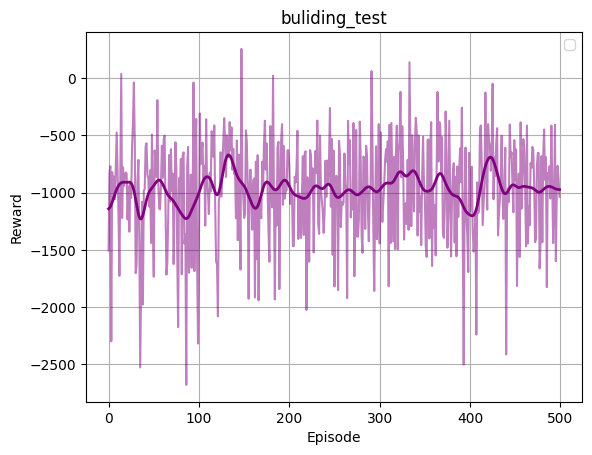

In [8]:
from scipy.ndimage import gaussian_filter1d
# 4 Save the rewards
reward_path = os.path.join(current_path, "model/" + scenario + f'/reward_{timestamp}.csv')
# np.savetxt(current_path + f'/epi_reward_{scenario}_{timestamp}.txt', EPISODE_REWARD_BUFFER)
np.savetxt(current_path + f'/epi_reward_{scenario}.txt', EPISODE_REWARD_BUFFER)
# 5 Plot the rewards
plt.plot(EPISODE_REWARD_BUFFER, color='purple', alpha=0.5)
plt.plot(np.arange(0, NUM_EPISODE, 1), gaussian_filter1d(EPISODE_REWARD_BUFFER, sigma=5), color='purple', linewidth=2)

plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title(f'{scenario}')
plt.legend()
plt.savefig(f"reward_{scenario}.png", format='png')
plt.grid()
plt.show()


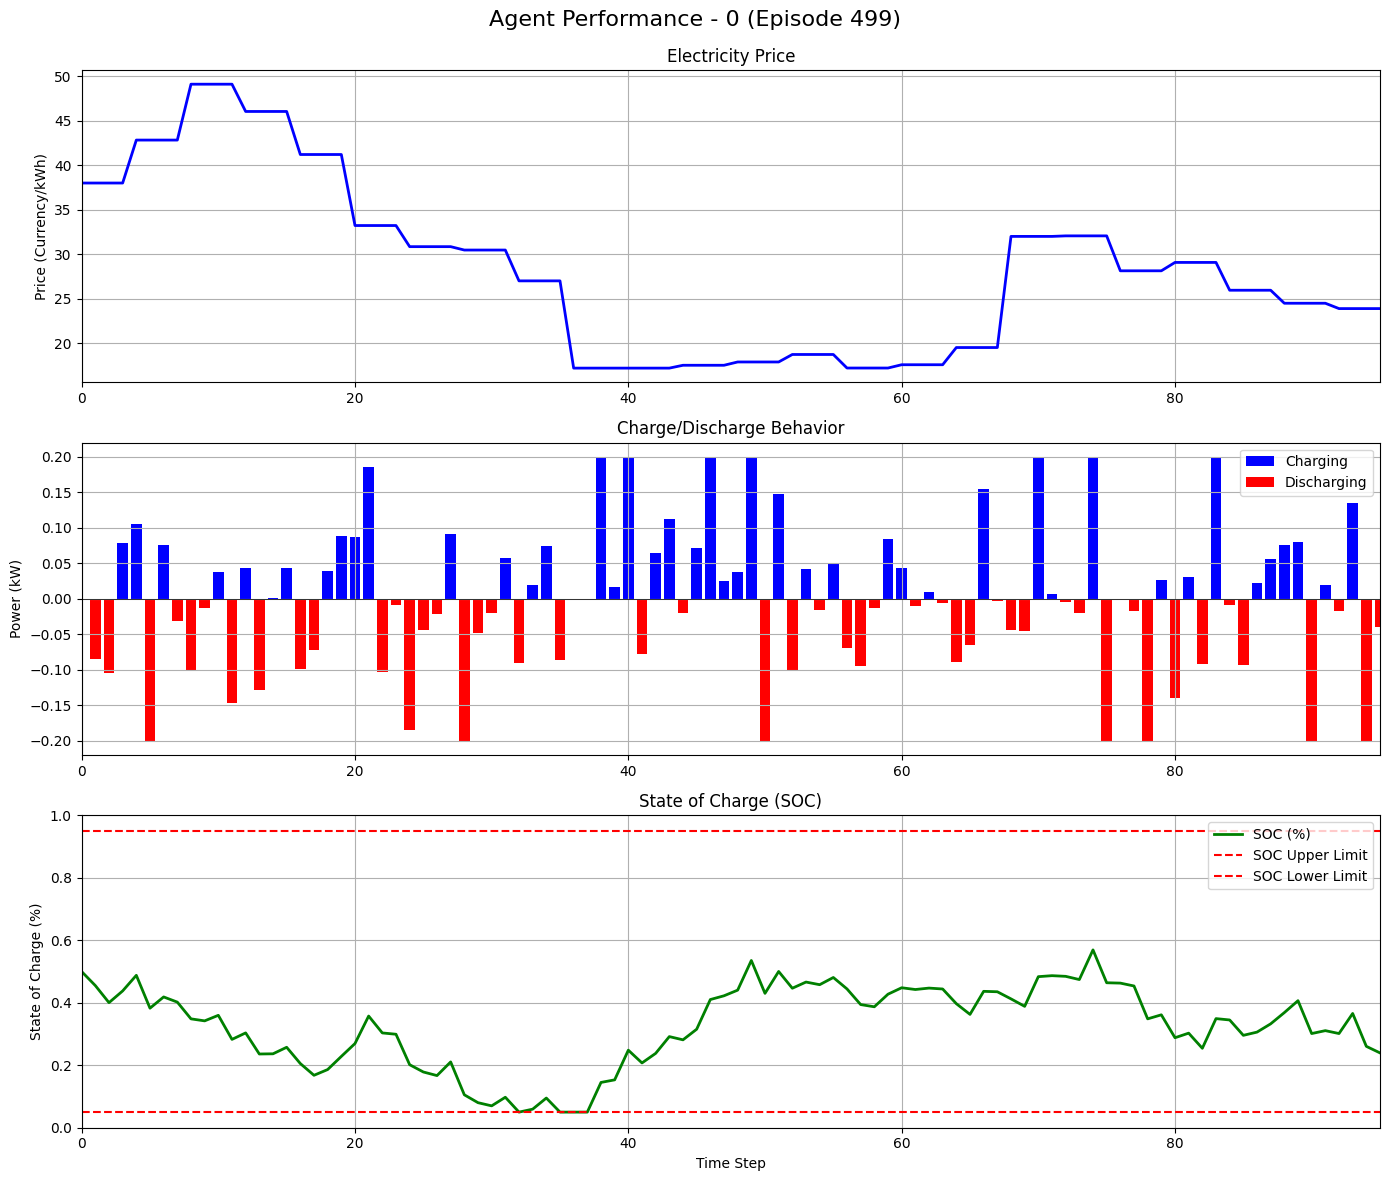

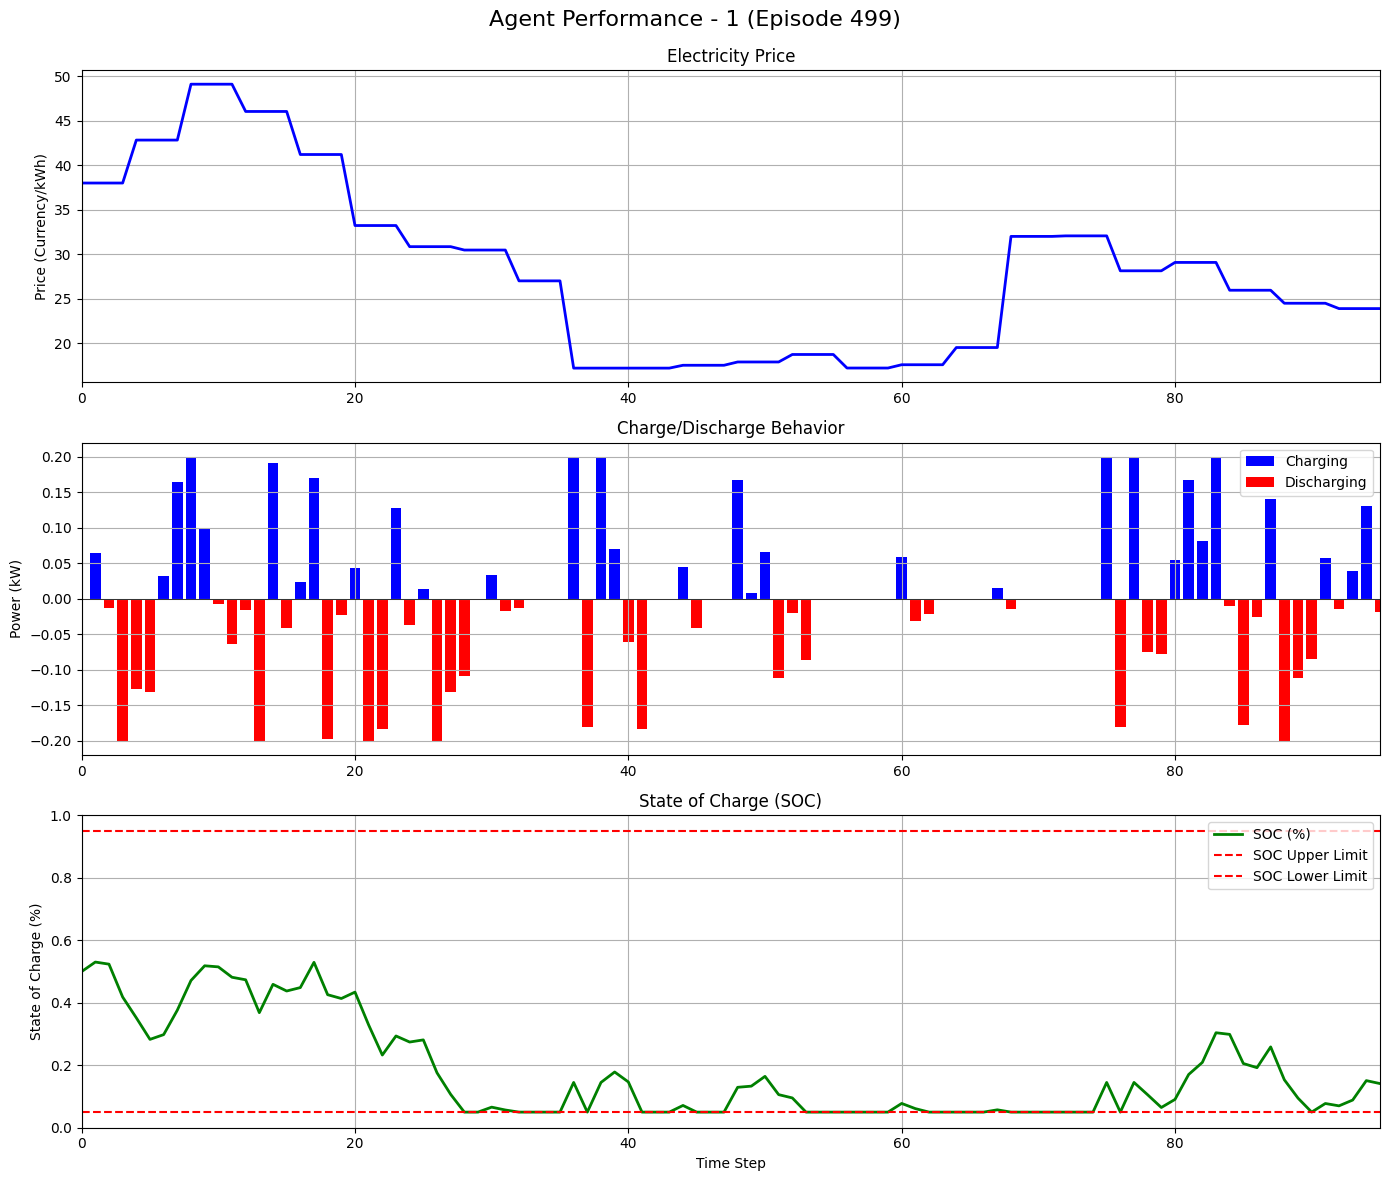

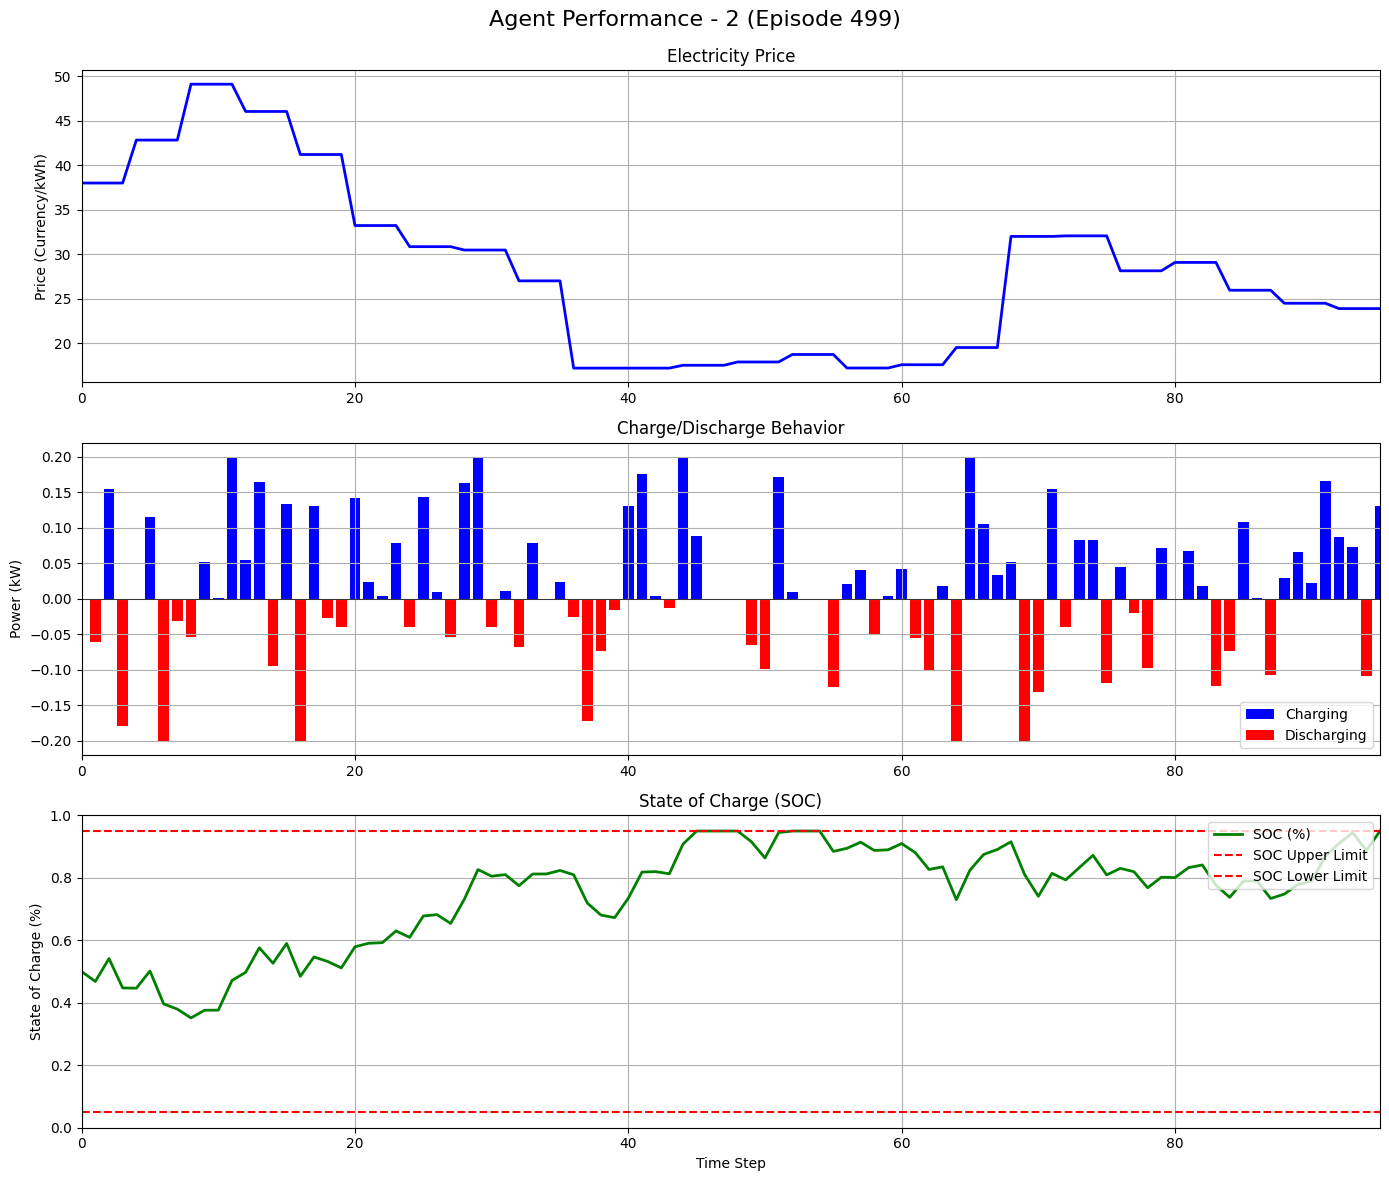

In [9]:
# 提取最后一代的数据（所有智能体）
last_episode = NUM_EPISODE - 1

# 为每个智能体创建图表
for agent_name in agent_name_list:
    # 获取该智能体的数据
    real_prices = agent_data[agent_name]['real_price'][last_episode]
    real_charges = agent_data[agent_name]['real_charge'][last_episode]
    real_soc_percent = agent_data[agent_name]['real_soc'][last_episode]
    real_loads = agent_data[agent_name]['real_load'][last_episode]
    
    # 确保所有数组长度一致（使用最小长度）
    num_steps = min(len(real_prices), len(real_charges), len(real_soc_percent), len(real_loads))
    
    # 如果SOC数据多了一个点（初始状态），我们只取动作执行后的点
    if len(real_soc_percent) == num_steps + 1:
        soc_percent = real_soc_percent[1:]  # 跳过初始状态
    else:
        soc_percent = real_soc_percent[:num_steps]
    
    # 截断其他数组以匹配长度
    times = np.arange(num_steps)
    prices = real_prices[:num_steps]
    charges = real_charges[:num_steps]
    loads = real_loads[:num_steps]
    
    # 计算净负荷
    net_loads = [loads[i] + charges[i] for i in range(num_steps)]
    
    # 创建包含三个子图的图表
    fig, axs = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle(f'Agent Performance - {agent_name} (Episode {last_episode})', fontsize=16)
    
    # 1. 电价波动图 (顶部)
    axs[0].plot(times, prices, 'b-', linewidth=2)
    axs[0].set_title('Electricity Price')
    axs[0].set_ylabel('Price (Currency/kWh)')
    axs[0].grid(True)
    axs[0].set_xlim(0, num_steps-1)
    
    # 2. 充放电行为图 (中部)
    charge_positive = [c if c >= 0 else 0 for c in charges]
    discharge_negative = [c if c < 0 else 0 for c in charges]
    
    axs[1].bar(times, charge_positive, width=0.8, color='blue', label='Charging')
    axs[1].bar(times, discharge_negative, width=0.8, color='red', label='Discharging')
    axs[1].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
    axs[1].set_title('Charge/Discharge Behavior')
    axs[1].set_ylabel('Power (kW)')
    axs[1].legend()
    axs[1].grid(True)
    axs[1].set_xlim(0, num_steps-1)
    
    # 3. SOC变化图 (底部)
    axs[2].plot(times, soc_percent, 'g-', linewidth=2, label='SOC (%)')
    
    # 添加SOC上下限标记
    soc_upper_limit = 0.95
    soc_lower_limit = 0.05
    axs[2].axhline(y=soc_upper_limit, color='r', linestyle='--', label='SOC Upper Limit')
    axs[2].axhline(y=soc_lower_limit, color='r', linestyle='--', label='SOC Lower Limit')
    
    axs[2].set_title('State of Charge (SOC)')
    axs[2].set_xlabel('Time Step')
    axs[2].set_ylabel('State of Charge (%)')
    axs[2].legend(loc='upper right')
    axs[2].grid(True)
    axs[2].set_xlim(0, num_steps-1)
    axs[2].set_ylim(0, 1.0)  # SOC范围0-1
    
    # 调整布局并保存
    plt.tight_layout()
    plt.subplots_adjust(top=0.93)
    plt.savefig(f"performance_{agent_name}.png", dpi=300)
    plt.show()

In [10]:
# After training is completed, save it to Excel
with pd.ExcelWriter('agent_training_data.xlsx') as writer:
    for agent_name in agent_name_list:
        # action
        action_df = pd.DataFrame.from_dict(
            agent_data[agent_name]['actions'], 
            orient='index'
        )
        action_df.index.name = 'Episode'
        action_df.columns = [f'Step_{i}' for i in range(action_df.shape[1])]
        action_df.to_excel(writer, sheet_name=f'{agent_name}_actions')
        
        # obs
        obs_records = []
        for ep in range(NUM_EPISODE):
            for step in range(len(agent_data[agent_name]['obs'][ep])):
                obs_records.append({
                    'Episode': ep,
                    'Step': step,
                    **{f'obs_dim_{i}': val 
                       for i, val in enumerate(agent_data[agent_name]['obs'][ep][step])}
                })
        
        obs_df = pd.DataFrame(obs_records).set_index(['Episode', 'Step'])
        obs_df.to_excel(writer, sheet_name=f'{agent_name}_obs')
        # 3. 真实值数据
        real_data_records = []
        for ep in range(NUM_EPISODE):
            if ep in agent_data[agent_name]['real_load']:
                steps = len(agent_data[agent_name]['real_load'][ep])
                for step in range(steps):
                    # 从环境获取电池容量信息（用于计算SOC百分比）
                    battery_capacity = env.battery_capacity
                    
                    real_data_records.append({
                        'Episode': ep,
                        'Step': step,
                        'real_load': agent_data[agent_name]['real_load'][ep][step],
                        'real_price': agent_data[agent_name]['real_price'][ep][step],
                        'real_charge': agent_data[agent_name]['real_charge'][ep][step],
                        'soc_percentage': agent_data[agent_name]['real_soc'][ep][step],
                        'soc_kwh': agent_data[agent_name]['real_soc'][ep][step] * battery_capacity
                    })
        
        real_data_df = pd.DataFrame(real_data_records).set_index(['Episode', 'Step'])
        real_data_df.to_excel(writer, sheet_name=f'{agent_name}_real_data')
print("The training data has been saved to agent_training_data.xlsx")

The training data has been saved to agent_training_data.xlsx
